# Проект на тему:
### «Анализ факторов увольнений (поиск инсайтов, составление рекомендаций стейкхолдерам)».

Кузьмичкин М. А.

Группа: DA-126

2026 г.


---





# Подключение библиотек

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Подключение источника данных

In [9]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Описание полей:

• ID – Идентификатор пользователя  
• Age – Возраст сотрудника  
• Attrition – Факт увольнения (Yes/No)  
• BusinessTravel – Частота командировок  
• DailyRate – Дневная ставка оплаты  
• Department – Отдел сотрудника  
• DistanceFromHome – Расстояние от дома до работы  
• Education – Уровень образования (числовая категория)  
• EducationField – Область образования  
• EmployeeCount – Количество сотрудников (константа)  
• EmployeeNumber – Уникальный идентификатор сотрудника  
• EnvironmentSatisfaction – Удовлетворенность рабочей средой  
• Gender – Пол сотрудника  
• HourlyRate – Почасовая ставка  
• JobInvolvement – Вовлеченность в работу  
• JobLevel – Уровень должности  
• JobRole – Должность  
• JobSatisfaction – Удовлетворенность работой  
• MaritalStatus – Семейное положение  
• MonthlyIncome – Месячный доход  
• MonthlyRate – Месячная ставка  
• NumCompaniesWorked – Количество компаний, в которых работал сотрудник  
• Over18 – Старше 18 лет  
• OverTime – Работает ли сверхурочно  
• PercentSalaryHike – Процент повышения зарплаты  
• PerformanceRating – Оценка производительности  
• RelationshipSatisfaction – Удовлетворенность отношениями на работе  
• StandardHours – Стандартное количество рабочих часов  
• StockOptionLevel – Уровень опционов на акции  
• TotalWorkingYears – Общий стаж работы  
• TrainingTimesLastYear – Количество тренингов за последний год  
• WorkLifeBalance – Баланс работы и личной жизни  
• YearsAtCompany – Стаж в текущей компании  
• YearsInCurrentRole – Стаж в текущей должности  
• YearsSinceLastPromotion – Лет с последнего повышения  
• YearsWithCurrManager – Лет работы с текущим менеджером  

# Предобработка данных

df.info показал, что в данных отсутствуют пропуски

In [21]:
df.duplicated().sum()

np.int64(0)

В данных отсутствуют дубликаты 

In [5]:
for col in list(df.columns):
    print(col, df[col].nunique())

Age 43
Attrition 2
BusinessTravel 3
DailyRate 886
Department 3
DistanceFromHome 29
Education 5
EducationField 6
EmployeeCount 1
EmployeeNumber 1470
EnvironmentSatisfaction 4
Gender 2
HourlyRate 71
JobInvolvement 4
JobLevel 5
JobRole 9
JobSatisfaction 4
MaritalStatus 3
MonthlyIncome 1349
MonthlyRate 1427
NumCompaniesWorked 10
Over18 1
OverTime 2
PercentSalaryHike 15
PerformanceRating 2
RelationshipSatisfaction 4
StandardHours 1
StockOptionLevel 4
TotalWorkingYears 40
TrainingTimesLastYear 7
WorkLifeBalance 4
YearsAtCompany 37
YearsInCurrentRole 19
YearsSinceLastPromotion 16
YearsWithCurrManager 18


Таким образом, в датасете есть EmployeeCount, Over18, StandardHours, которые все имеют по 1 значению. То есть эти переменные в принципе не несут никакой информативной ценности, а только нагружают датасет.
Также в датасете присутствует EmployeeNumber, который является идентификатором работника. Потенциально переменная может оказаться полезной

# Преобразования данных

In [6]:
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours']) 
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0) # ушел = 1 
df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0) # мужчина = 1 
df['OverTime'] = df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0) # работает сверхурочно = 1 
df['BusinessTravel'] = df['BusinessTravel'].apply(lambda x: 0 if x == 'Non-Travel' else 1 if x == 'Travel_Rarely' else 2) # не ездит в командировки = 0, ездит редко = 1, ездит часто = 2

In [7]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,2,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,1,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,2,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,0,1,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,2,884,Research & Development,23,2,Medical,2061,3,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,1,613,Research & Development,6,1,Medical,2062,4,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,1,155,Research & Development,4,3,Life Sciences,2064,2,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,2,1023,Sales,2,3,Medical,2065,4,...,3,4,0,17,3,2,9,6,0,8


In [8]:
df.describe()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,1.086395,802.485714,9.192517,2.912925,1024.865306,2.721769,0.600000,65.891156,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,0.532170,403.509100,8.106864,1.024165,602.024335,1.093082,0.490065,20.329428,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,0.000000,102.000000,1.000000,1.000000,1.000000,1.000000,0.000000,30.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,1.000000,465.000000,2.000000,2.000000,491.250000,2.000000,0.000000,48.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,1.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,1.000000,66.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,1.000000,83.750000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,2.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,1.000000,100.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [79]:
df[df['TotalWorkingYears'] > df['Age']]
df[df['YearsAtCompany'] > df['TotalWorkingYears']]
df[df['YearsInCurrentRole'] > df['YearsAtCompany']]
df[df['YearsWithCurrManager'] > df['YearsAtCompany']]
df[df['YearsSinceLastPromotion'] > df['YearsAtCompany']]
df[df['TotalWorkingYears'] > df['Age']]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


Ни один из фильтров не дал записей в датафрейме. Таким образом, в датасете нет нарушений логических взаимосвязей 

In [80]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

q05 = df[numeric_cols].quantile(0.05)
q95 = df[numeric_cols].quantile(0.95)

mask = (df[numeric_cols] < q05) | (df[numeric_cols] > q95)

df_outl = df[mask.any(axis=1)]
df_outl

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1,1102,Sales,1,2,Life Sciences,1,2,0,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,0,2,279,Research & Development,8,1,Life Sciences,2,3,1,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,1,1373,Research & Development,2,2,Other,4,4,1,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,0,2,1392,Research & Development,3,4,Life Sciences,5,4,0,56,3,1,Research Scientist,3,Married,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,0,1,591,Research & Development,2,1,Medical,7,1,1,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,2,884,Research & Development,23,2,Medical,2061,3,1,41,4,2,Laboratory Technician,4,Married,2571,12290,4,0,17,3,3,1,17,3,3,5,2,0,3
1466,39,0,1,613,Research & Development,6,1,Medical,2062,4,1,42,2,3,Healthcare Representative,1,Married,9991,21457,4,0,15,3,1,1,9,5,3,7,7,1,7
1467,27,0,1,155,Research & Development,4,3,Life Sciences,2064,2,1,87,4,2,Manufacturing Director,2,Married,6142,5174,1,1,20,4,2,1,6,0,3,6,2,0,3
1468,49,0,2,1023,Sales,2,3,Medical,2065,4,1,63,2,2,Sales Executive,2,Married,5390,13243,2,0,14,3,4,0,17,3,2,9,6,0,8


# Анализ данных

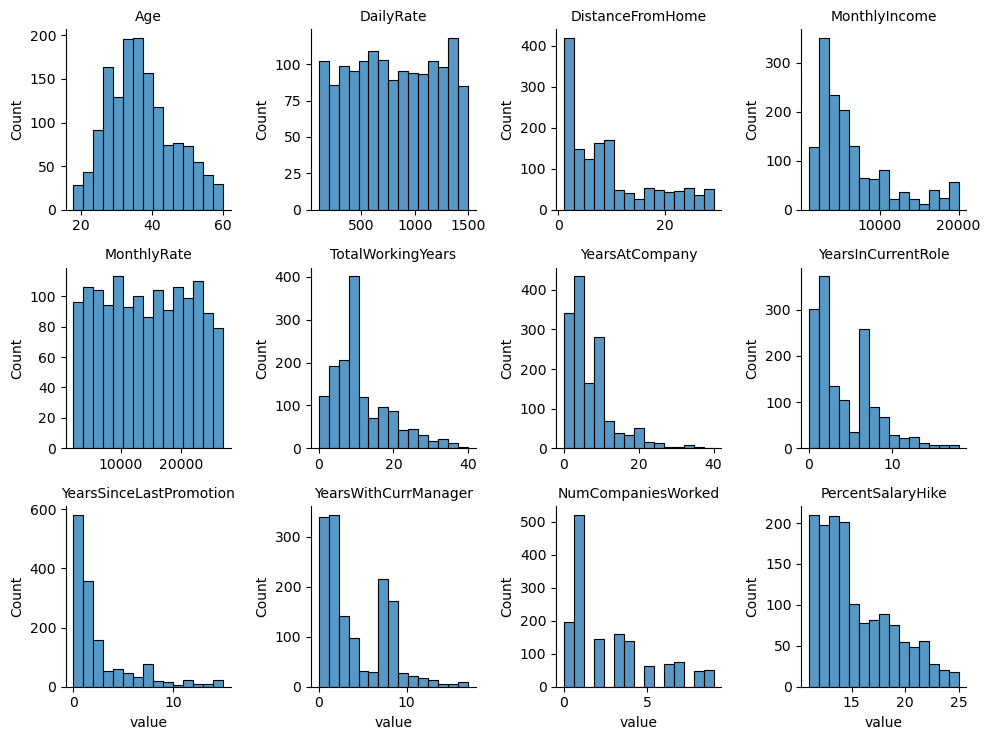

In [81]:
var = ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'MonthlyRate', 'TotalWorkingYears', 'YearsAtCompany', 
'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'PercentSalaryHike']

df_his = pd.melt(df[variables])

grid = sns.FacetGrid(df_his, col='variable', col_wrap=4, sharex=False, sharey=False, height=2.5)
grid.map(sns.histplot, 'value', bins=15)
grid.set_titles(col_template='{col_name}')
plt.show()

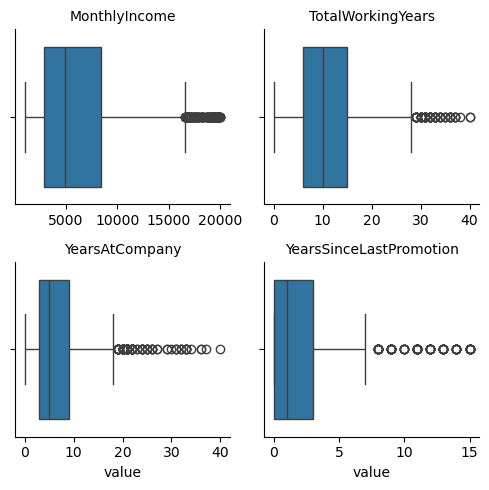

In [82]:
int_boxpl = ['MonthlyIncome' , 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion']

df_box = pd.melt(df[int_boxpl])

grid = sns.FacetGrid(df_box, col='variable', col_wrap=2, sharex=False, sharey=False, height=2.5)
grid.map_dataframe(sns.boxplot, x= 'value')
grid.set_titles(col_template='{col_name}')
plt.show()

# Анализ для HR

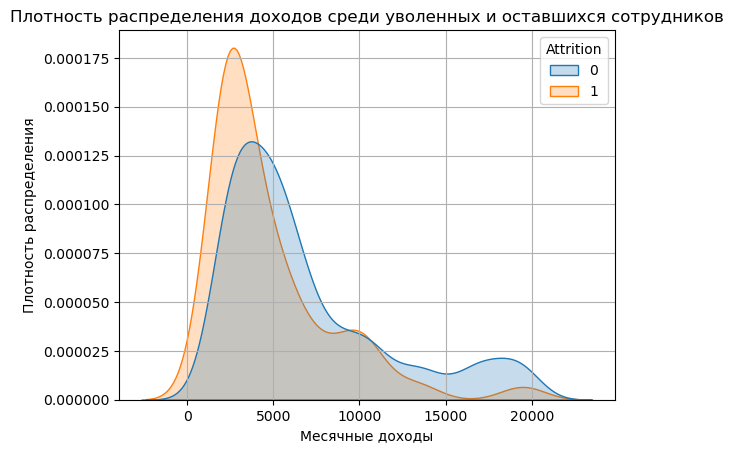

In [67]:
sns.kdeplot(data=df, x='MonthlyIncome', hue='Attrition', fill=True, common_norm=False)
plt.title('Плотность распределения доходов среди уволенных и оставшихся сотрудников')
plt.ylabel('Плотность распределения')
plt.xlabel('Месячные доходы')
plt.grid()
plt.show()

Вывод: Основной отток сосредоточен среди наименее оплачиваемых сотрудников. 


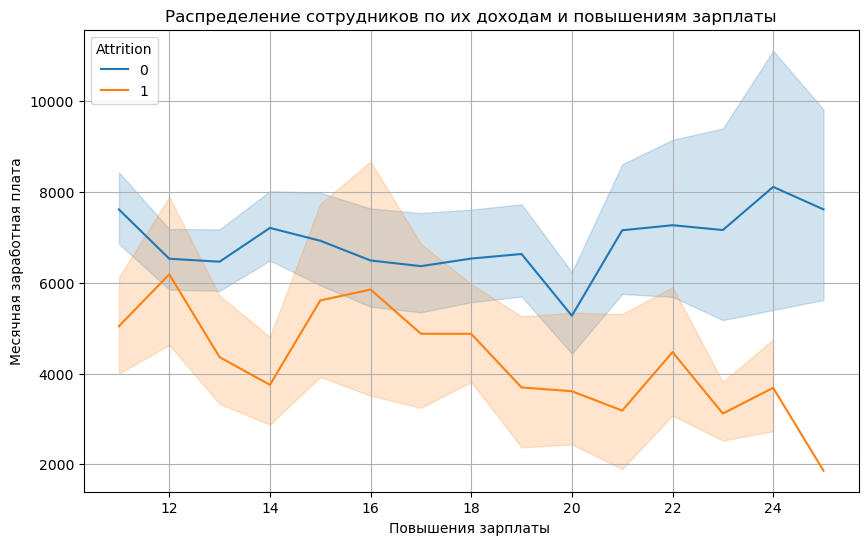

In [7]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='PercentSalaryHike', y='MonthlyIncome', hue='Attrition')
plt.title('Распределение сотрудников по их доходам и повышениям зарплаты')
plt.xlabel('Повышения зарплаты ')
plt.ylabel('Месячная заработная плата')
plt.grid()
plt.show()

Вывод: Уволившиеся сотрудники имеют уровень дохода ниже, чем оставшиеся. Повышение зарплаты не устраняет этот разрыв. 

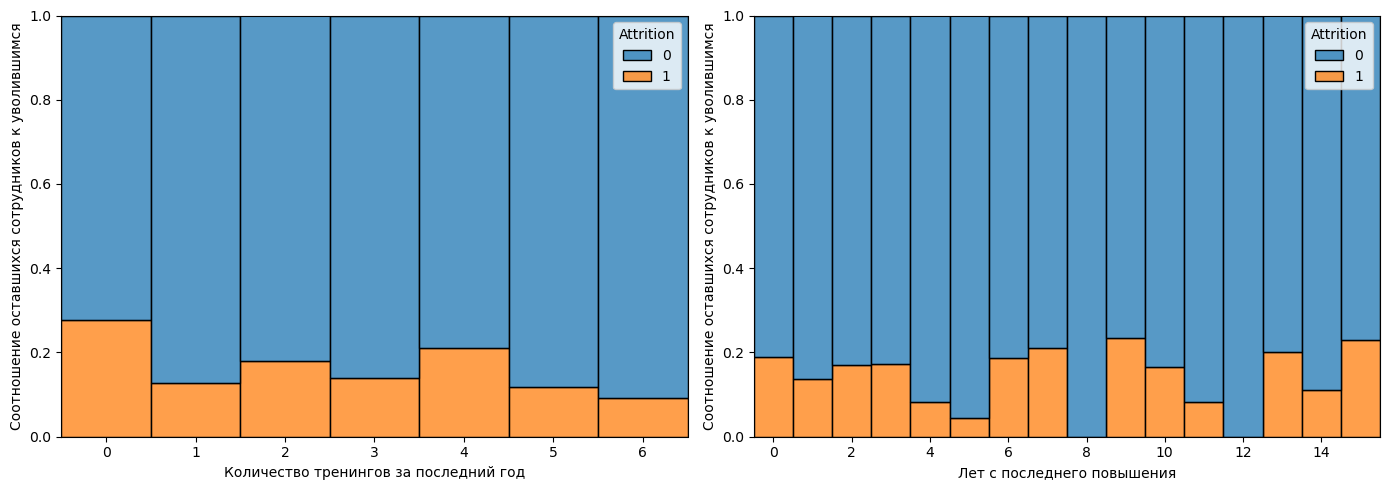

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='TrainingTimesLastYear', hue='Attrition', multiple='fill', stat='proportion', discrete=True, bins=20, ax=axes[0])
axes[0].set_xlabel('Количество тренингов за последний год')
axes[0].set_ylabel('Соотношение оставшихся сотрудников к уволившимся')

sns.histplot(data=df, x='YearsSinceLastPromotion', hue='Attrition', multiple='fill', stat='proportion', discrete=True, bins=30, ax=axes[1])
axes[1].set_xlabel('Лет с последнего повышения')
axes[1].set_ylabel('Соотношение оставшихся сотрудников к уволившимся')

plt.tight_layout()
plt.show()

Вывод: Если сотрудник был хотя бы на одном тренинге за последний год, вероятность того, что он уйдет снижается, однако снижение не пропорционально количеству тренингов. 
Кроме того, отсутствует четкая зависимость между количеством лет с последнего повышения и оттоком кадров.


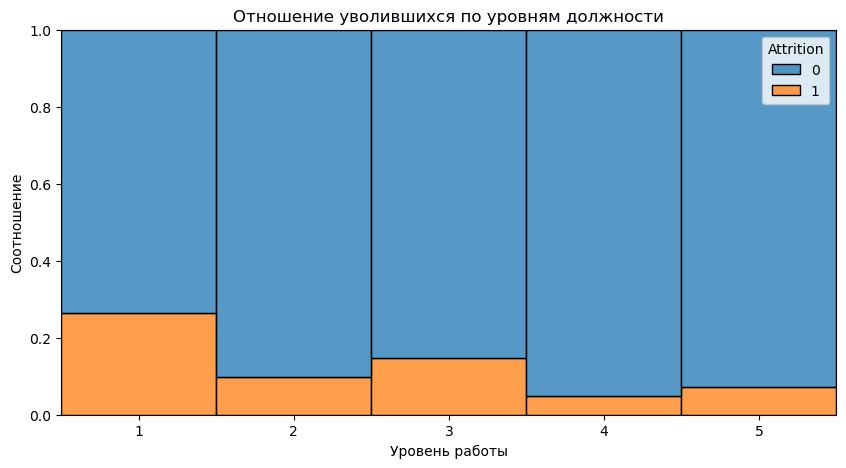

In [95]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='JobLevel', hue='Attrition', multiple='fill', stat='proportion', discrete=True)
plt.title('Отношение уволившихся по уровням должности')
plt.xlabel('Уровень должности')
plt.ylabel('Соотношение')
plt.show()

Вывод: Повышение уровня должности снижает риск увольнения


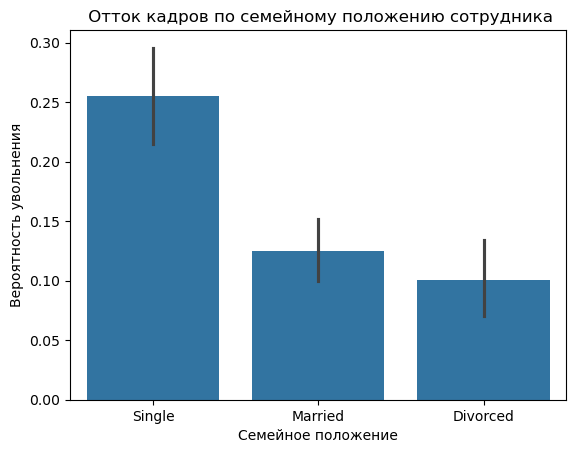

In [8]:
sns.barplot(data=df, x='MaritalStatus', y='Attrition')
plt.title(' Отток кадров по семейному положению сотрудника')
plt.xlabel('Семейное положение')
plt.ylabel('Вероятность увольнения')
plt.show()

Вывод: Наибольший отток наблюдается по одиноким сотрудникам, наименьший по разведенным.


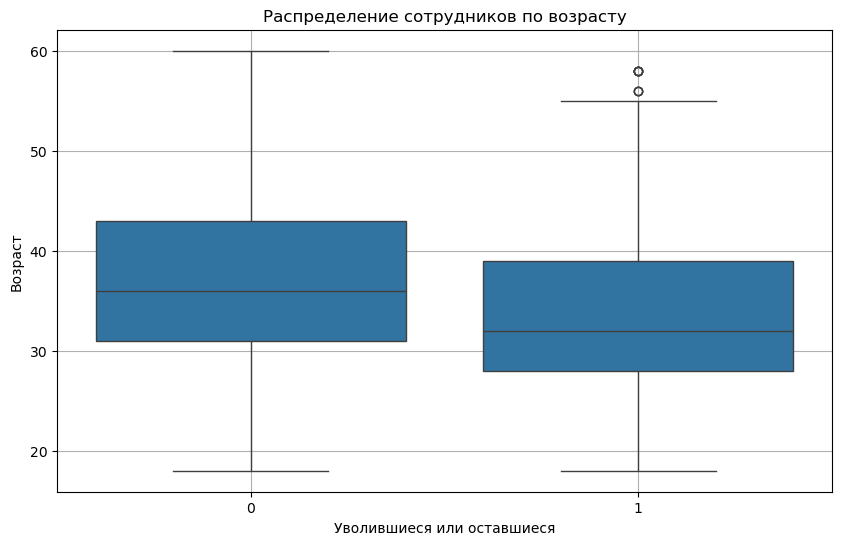

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition', y='Age')
plt.title('Распределение сотрудников по возрасту')
plt.xlabel('Уволившиеся или оставшиеся')
plt.ylabel('Возраст')
plt.grid()
plt.show()

Вывод: Основной состав работников – зрелая возрастная группа. Уволившиеся сотрудники зачастую моложе.

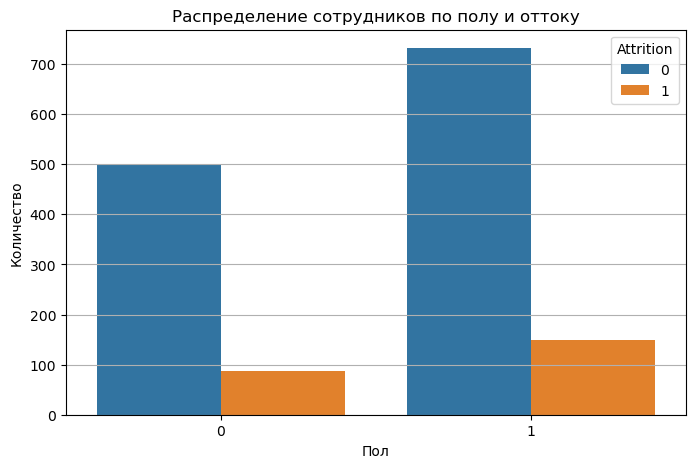

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Gender', hue='Attrition')
plt.title('Распределение сотрудников по полу и оттоку')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.grid(axis = 'y')
plt.show()

Вывод: Большая часть людей в компании – мужчины. Среди покинувших мужчины также составляют большую часть. 

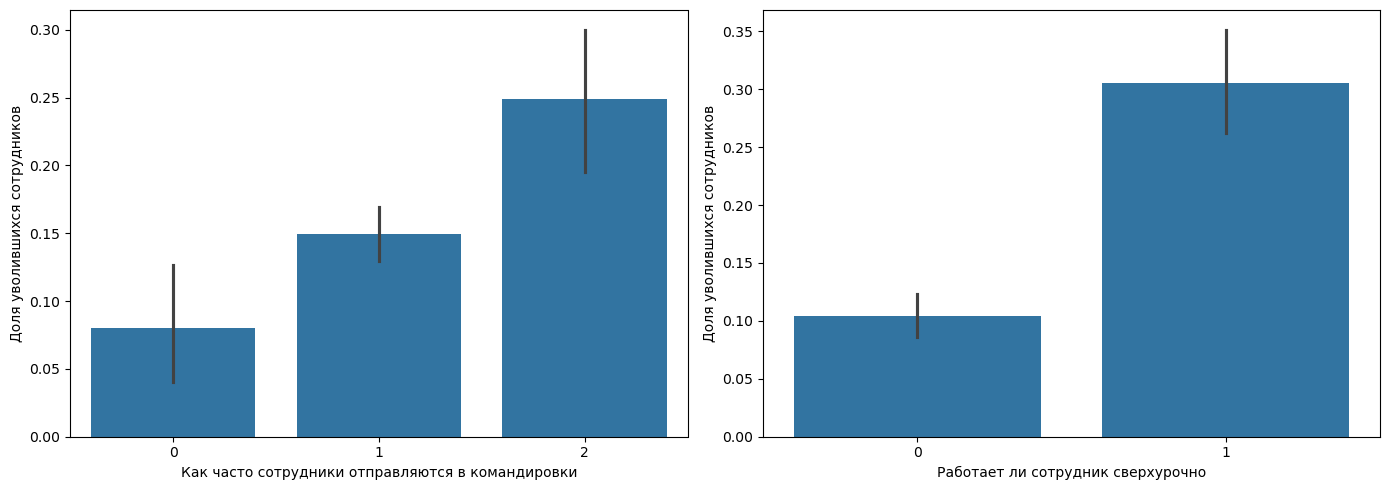

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='BusinessTravel', y='Attrition', ax=axes[0])
axes[0].set_xlabel('Как часто сотрудники отправляются в командировки')
axes[0].set_ylabel('Доля уволившихся сотрудников')

sns.barplot(data=df, x='OverTime', y='Attrition', ax=axes[1])
axes[1].set_xlabel('Работает ли сотрудник сверхурочно')
axes[1].set_ylabel('Доля уволившихся сотрудников')

plt.tight_layout()
plt.show()

Вывод: Сотрудники, которые отправляются на командировки чаще, имеют более высокие шансы уволиться. Сотрудники, работающие сверхурочно, вероятно, имеют более высокую загрузку и чаще значительно увольняются.


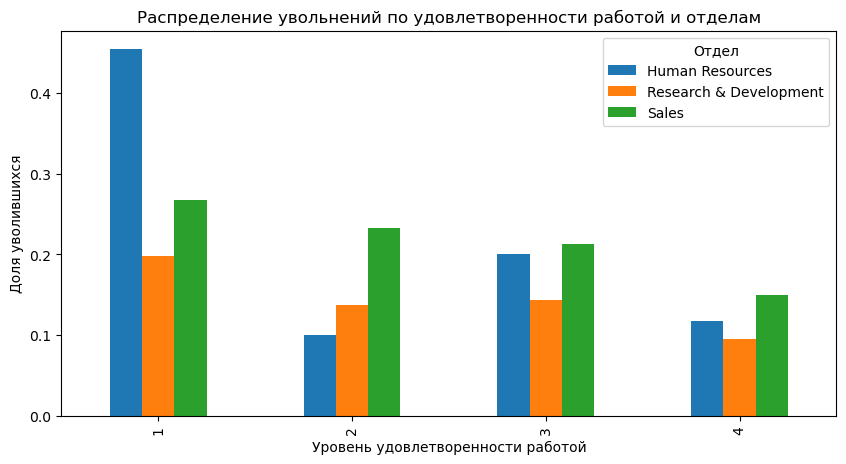

In [13]:
attrition_jobsat_dep = df.groupby(['Department', 'JobSatisfaction'])['Attrition'].mean().unstack()

attrition_jobsat_dep.T.plot(kind='bar', figsize=(10, 5))
plt.title('Распределение увольнений по удовлетворенности работой и отделам')
plt.xlabel('Уровень удовлетворенности работой')
plt.ylabel('Доля уволившихся')
plt.legend(title='Отдел')
plt.show()

Вывод: Наибольший отток кадров наблюдается в группе людей с низкой удовлетворенностью своей работой. Для наименее удовлетворенных своей работой отделом с максимальным оттоком является отдел кадров, с минимальным – отдел научных исследований и развития. Заметна тенденция к снижению оттока кадров по мере увеличения удовлетворенности. 


# Высший менеджмент

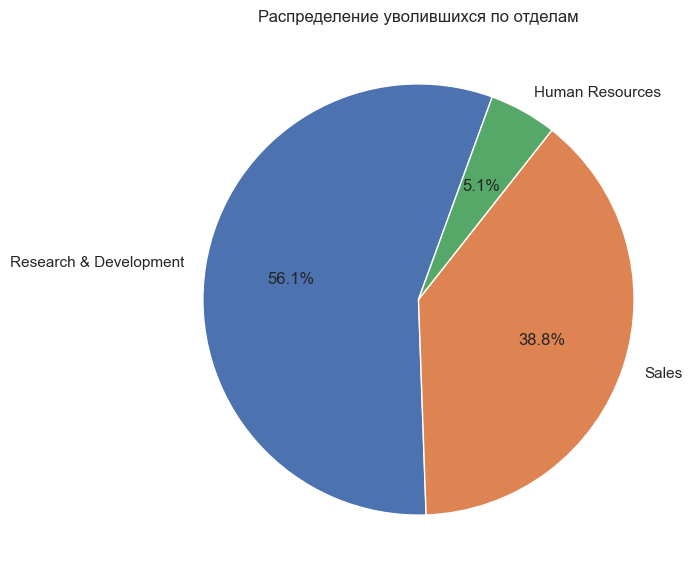

In [28]:
attrited = df[df['Attrition'] == 1]
dep_counts = attrited['Department'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(x = dep_counts, labels = dep_counts.index, autopct = '%1.1f%%', startangle=70)
plt.title('Распределение уволившихся по отделам')
plt.show()

Вывод: Среди всех уволившихся сотрудников 56% приходятся на отдел научных исследований и развития, 38% на отдел продаж и только 5% на отдел кадров. 

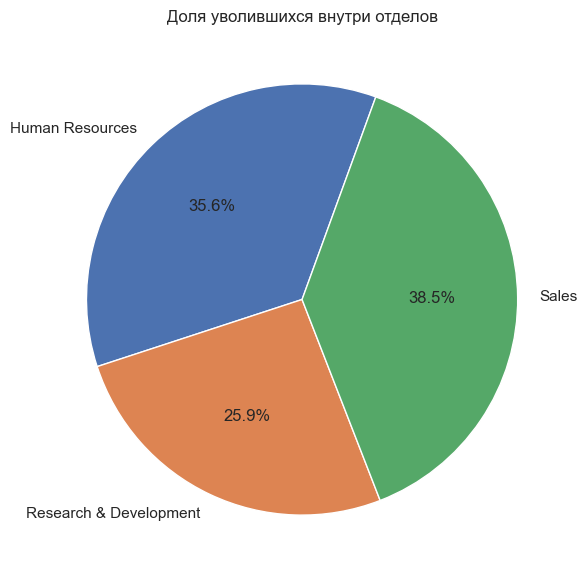

In [27]:
dep_attr_rate = df.groupby('Department')['Attrition'].mean()

plt.figure(figsize=(7,7))
plt.pie(dep_attrition_rate, labels=dep_attrition_rate.index, autopct='%1.1f%%', startangle=70)
plt.title('Доля уволившихся внутри отделов')
plt.show()

Вывод: Доля уволившихся сотрудников в отделе продаж максимальна и составляет 38,5%. В отделе кадров было уволено 35,6% сотрудников, а в отделе научных исследований и развития только 25,9%.

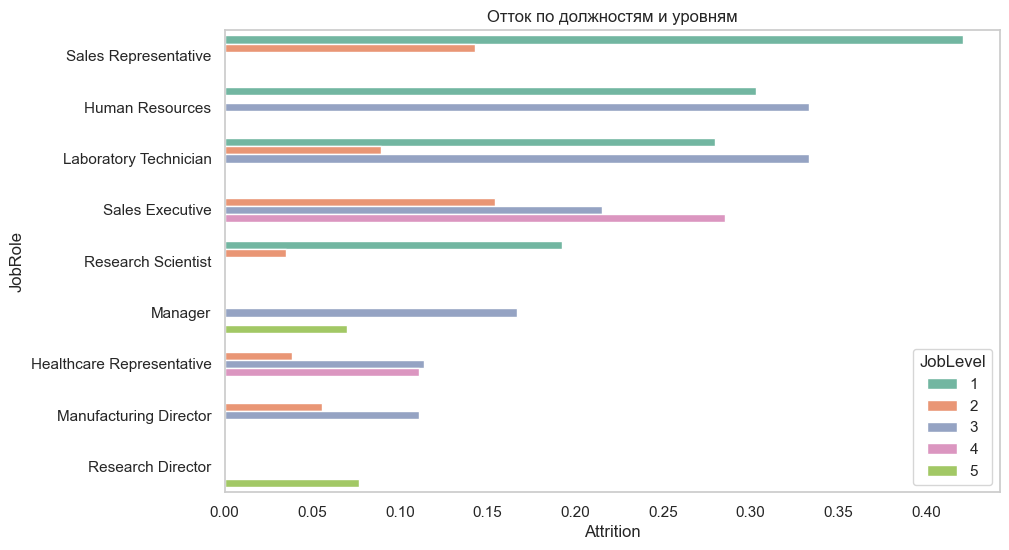

In [26]:
role_lvl = df.groupby(['JobRole', 'JobLevel'], as_index=False)['Attrition'].mean()
role_lvl = role_lvl.sort_values(by='Attrition', ascending=False)

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=role_lvl, x='Attrition', y='JobRole', hue='JobLevel', palette='Set2')
plt.grid(axis = 'x')
plt.title('Отток по должностям и уровням')
plt.show()

Вывод: По мере повышения уровня должности отток кадров снижается. Наибольший отток демонстрируют представители отдела продаж, отдела кадров и техники в лабораториях. Наибольший отток наблюдается по начальному и среднему уровням должности. 


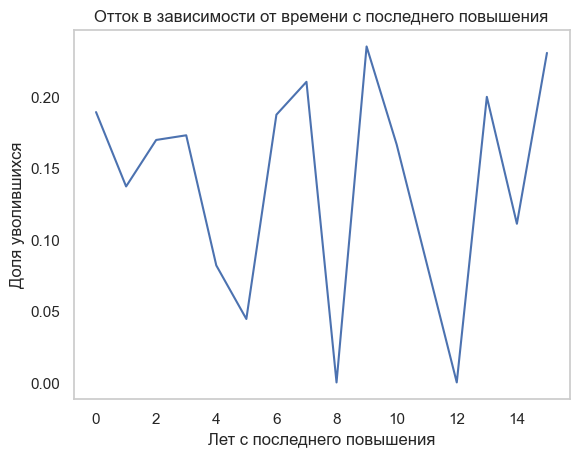

In [32]:
attr_by_prom = df.groupby('YearsSinceLastPromotion')['Attrition'].mean()

sns.lineplot(data = attr_by_prom)
plt.title('Отток в зависимости от времени с последнего повышения')
plt.xlabel('Лет с последнего повышения')
plt.ylabel('Доля уволившихся')
plt.grid()
plt.show()

Вывод: Четкой зависимости между временем с последнего повышения и оттоком не наблюдается.

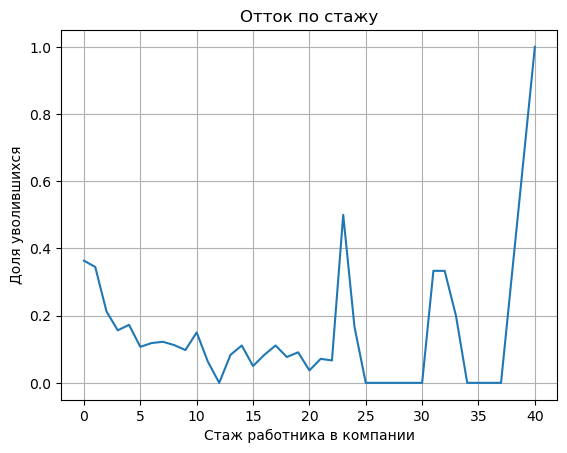

In [21]:
attr_by_years = df.groupby('YearsAtCompany')['Attrition'].mean()

sns.lineplot(data = attr_by_years)
plt.grid()
plt.title('Отток по стажу')
plt.xlabel('Стаж работника в компании')
plt.ylabel('Доля уволившихся')
plt.show()

Вывод: Вероятность уйти из компании снижается по мере повышения стажа.


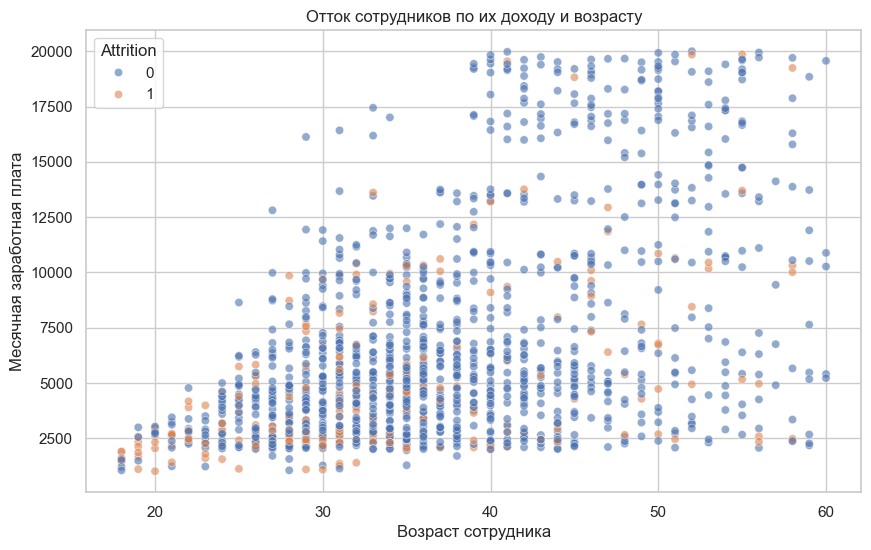

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='MonthlyIncome', hue='Attrition', alpha=0.6)
plt.title('Отток сотрудников по их доходу и возрасту')
plt.xlabel('Возраст сотрудника')
plt.ylabel('Месячная заработная плата')
plt.show()

Вывод: Большая часть уволенных сотрудников – люди молодого и среднего возраста, имеющие невысокую и среднюю по меркам компании заработную плату. 


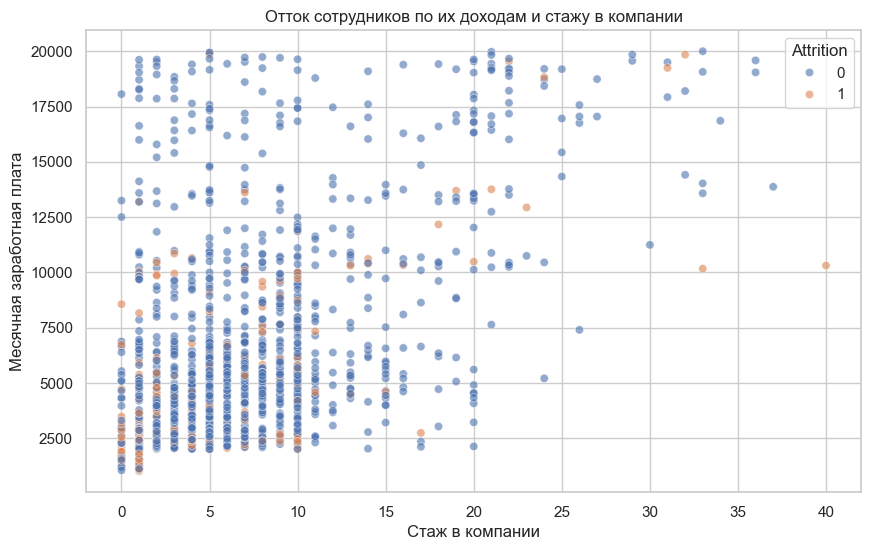

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='YearsAtCompany', y='MonthlyIncome', hue='Attrition', alpha=0.6)
plt.title('Отток сотрудников по их доходам и стажу в компании')
plt.xlabel('Стаж в компании')
plt.ylabel('Месячная заработная плата')
plt.show()

Вывод: Большая часть уволенных сотрудников сконцентрирована в пределах 3 лет стажа и 5000у.е. заработной платы. Большая часть всех сотрудников сконцентрирована в пределах 10 лет стажа и 10000у.е. заработной платы.


# Менеджерам

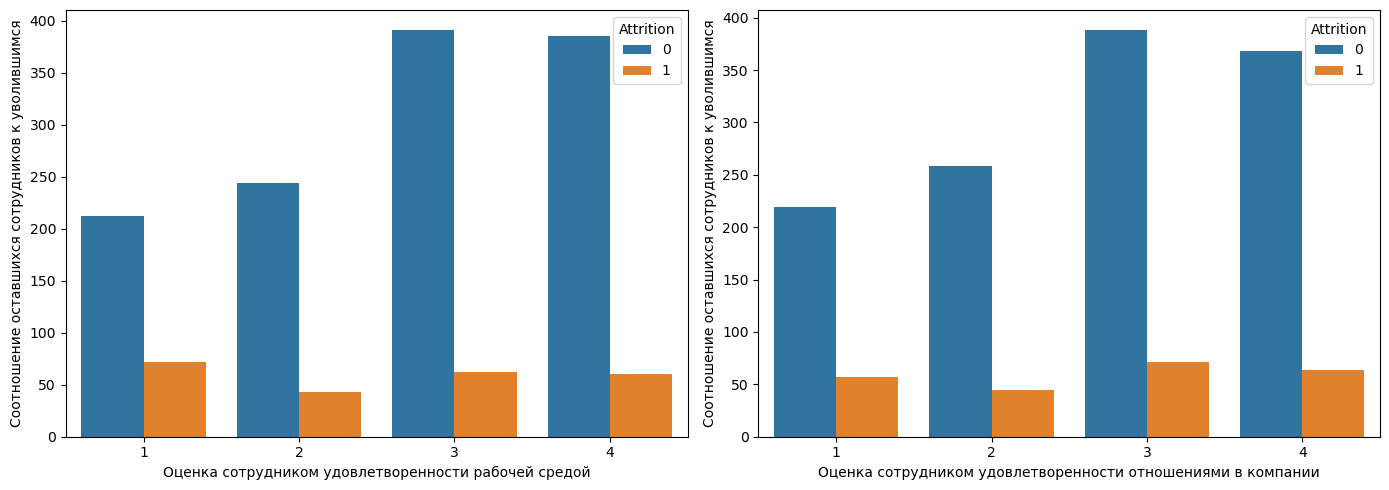

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data = df, x = 'EnvironmentSatisfaction', hue = 'Attrition', ax=axes[0])
axes[0].set_xlabel('Оценка сотрудником удовлетворенности рабочей средой')
axes[0].set_ylabel('Соотношение оставшихся сотрудников к уволившимся')

sns.countplot(data = df, x = 'RelationshipSatisfaction', hue = 'Attrition', ax=axes[1])
axes[1].set_xlabel('Оценка сотрудником удовлетворенности отношениями в компании')
axes[1].set_ylabel('Соотношение оставшихся сотрудников к уволившимся')
plt.tight_layout()
plt.show()

Вывод: По мере роста удовлетворенности сотрудника рабочей средой и отношениями в компании процентное соотношение уволенных сотрудников снижается. 

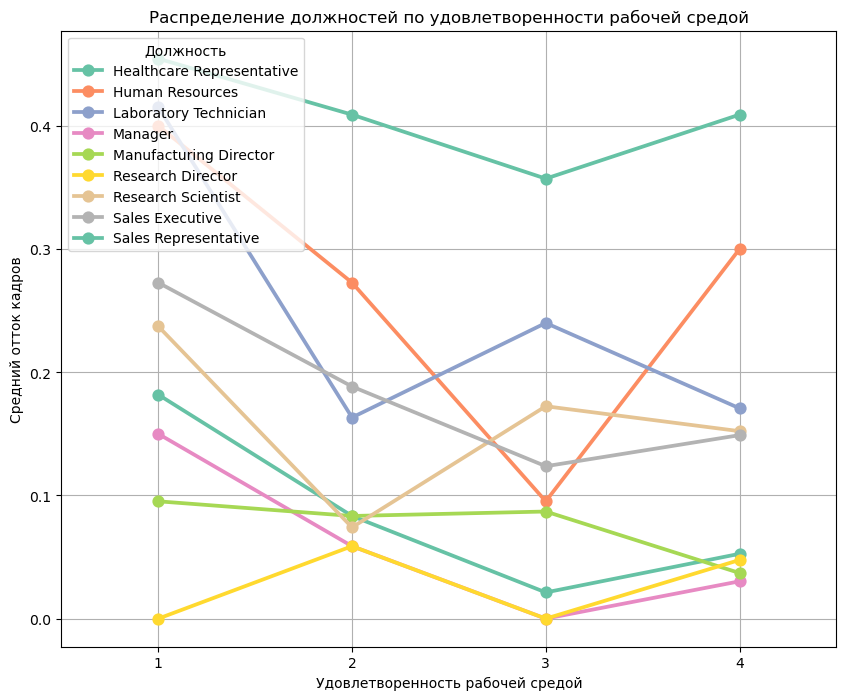

In [12]:
envsat_jobr = df.groupby(['EnvironmentSatisfaction', 'JobRole'], as_index=False)['Attrition'].mean()

plt.figure(figsize=(10,8))
sns.pointplot(data=envsat_jobr, x='EnvironmentSatisfaction', y='Attrition', hue='JobRole', palette = 'Set2')
plt.title('Распределение должностей по удовлетворенности рабочей средой')
plt.xlabel('Удовлетворенность рабочей средой')
plt.ylabel('Средний отток кадров')
plt.legend(title = 'Должность',loc='upper left')
plt.grid()
plt.show()

Вывод: Рост удовлетворенности рабочей средой снижает отток кадров, однако сила эффекта различается по должностям. Для некоторых позиций отток остается высоким вне зависимости от удовлетворенности.


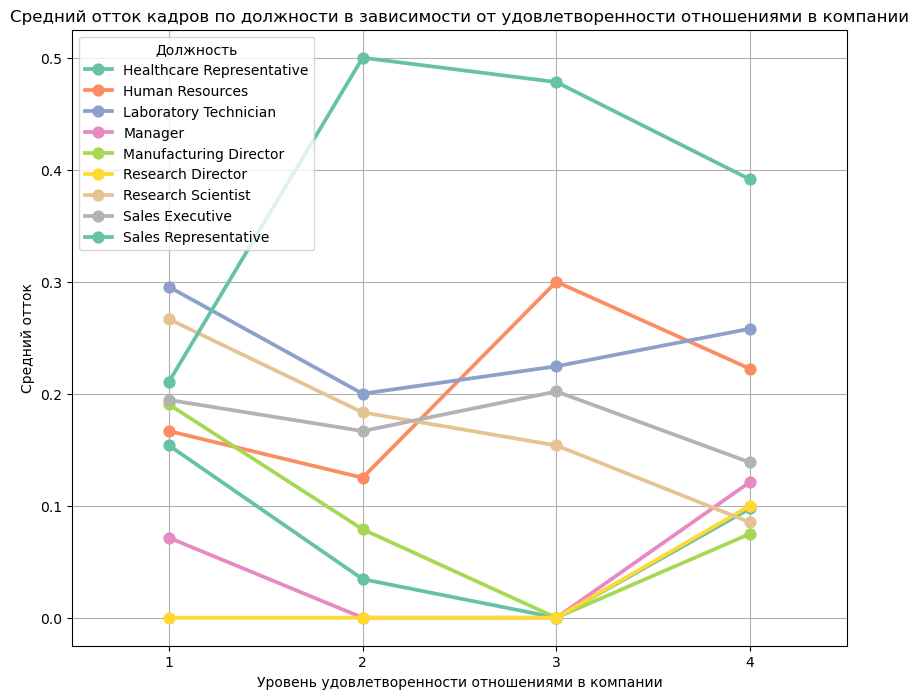

In [14]:
plt.figure(figsize=(10,8))
relsat_jobr = df.groupby(['RelationshipSatisfaction', 'JobRole'], as_index=False)['Attrition'].mean()
sns.pointplot(data=relsat_jobr, x='RelationshipSatisfaction', y='Attrition', hue='JobRole', palette = 'Set2')
plt.title('Средний отток кадров по должности в зависимости от удовлетворенности отношениями в компании')
plt.xlabel('Уровень удовлетворенности отношениями в компании')
plt.ylabel('Средний отток')
plt.legend(title = 'Должность')
plt.grid()
plt.show()

Вывод: Однозначный вывод о влиянии удовлетворенности отношениями в компании сделать нельзя. Для некоторых должностей этот фактор снижает отток, для других – с ростом удовлетворенности растет и отток кадров.


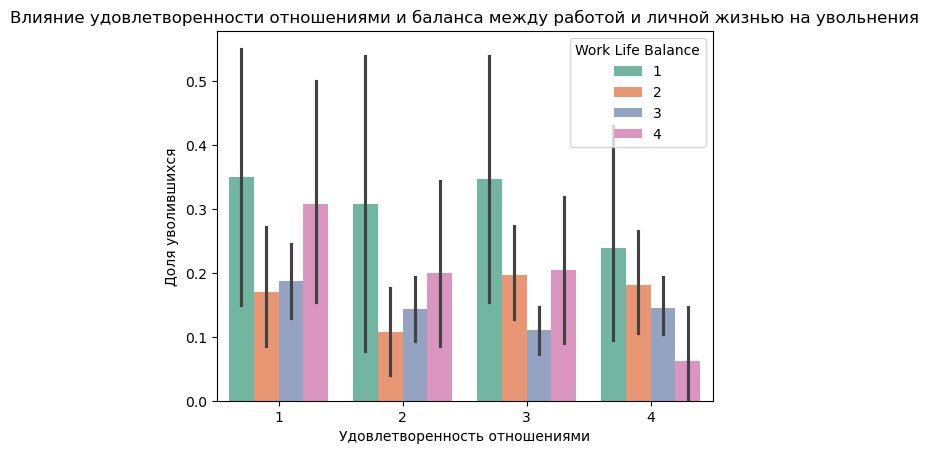

In [15]:
sns.barplot(data=df, x='RelationshipSatisfaction', y='Attrition', hue='WorkLifeBalance',palette='Set2')
plt.xlabel('Удовлетворенность отношениями')
plt.ylabel('Доля уволившихся')
plt.title('Влияние удовлетворенности отношениями и баланса между работой и личной жизнью на увольнения')
plt.legend(title='Work Life Balance')
plt.show()

Вывод: По мере повышения удовлетворенности отношениями в компании общий отток снижается. Однако для отдельных отношений баланса работы и личной жизни наблюдаются различные тенденции.


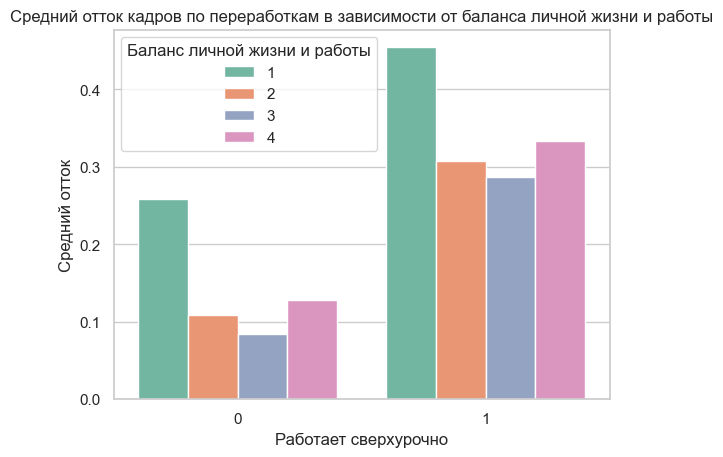

In [42]:
worklb_overtime = df.groupby(['WorkLifeBalance', 'OverTime'], as_index = False)['Attrition'].mean()

sns.barplot(data = worklb_overtime, x = 'OverTime', y = 'Attrition', hue = 'WorkLifeBalance', palette='Set2')
plt.title('Средний отток кадров по переработкам в зависимости от баланса личной жизни и работы')
plt.xlabel('Работает сверхурочно')
plt.ylabel('Средний отток')
plt.legend(title='Баланс личной жизни и работы')
plt.show()

Вывод: Наблюдается однозначная тенденция на повышение увольнений для всех вариантов баланса личной жизни и работы.


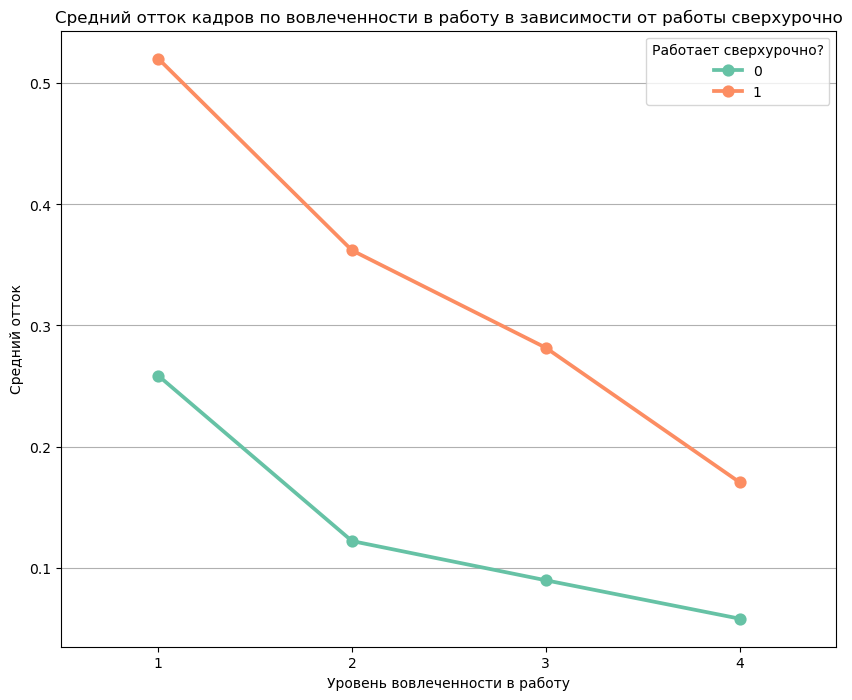

In [6]:
jobinv_overtime = df.groupby(['JobInvolvement', 'OverTime'], as_index=False)['Attrition'].mean()

plt.figure(figsize=(10,8))
sns.pointplot(data=jobinv_overtime, x='JobInvolvement', y='Attrition', hue = 'OverTime',  palette='Set2')
plt.title('Средний отток кадров по вовлеченности в работу в зависимости от работы сверхурочно')
plt.xlabel('Уровень вовлеченности в работу')
plt.ylabel('Средний отток')
plt.grid(axis = 'y')
plt.legend(title = 'Работает сверхурочно?')
plt.show()

Вывод: Уровень вовлеченности в работу однозначно снижает отток кадров, однако наблюдается расслоение между работающими сверхурочно сотрудниками и не работающими. Для работающих сверхурочно характерен повышенный риск увольнения.  


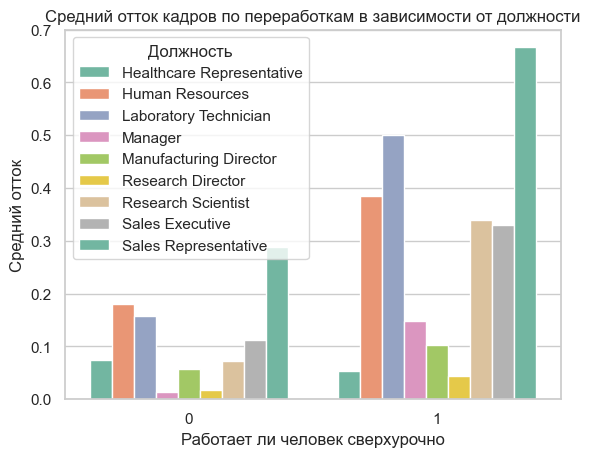

In [39]:
jobrole_overtime = df.groupby(['JobRole', 'OverTime'], as_index = False)['Attrition'].mean()

sns.barplot(data = jobrole_overtime, x = 'OverTime', y = 'Attrition', hue = 'JobRole', palette='Set2')
plt.title('Средний отток кадров по переработкам в зависимости от должности')
plt.xlabel('Работает ли человек сверхурочно')
plt.ylabel('Средний отток')
plt.legend(title='Должность')
plt.show()

Вывод: Работа сверхурочно однозначно повышает отток кадров, но для каждой должности эффект свой. Наибольший эффект переработки оказывают на представителей здравоохранения, сотрудников отдела кадров, лаборантов.  


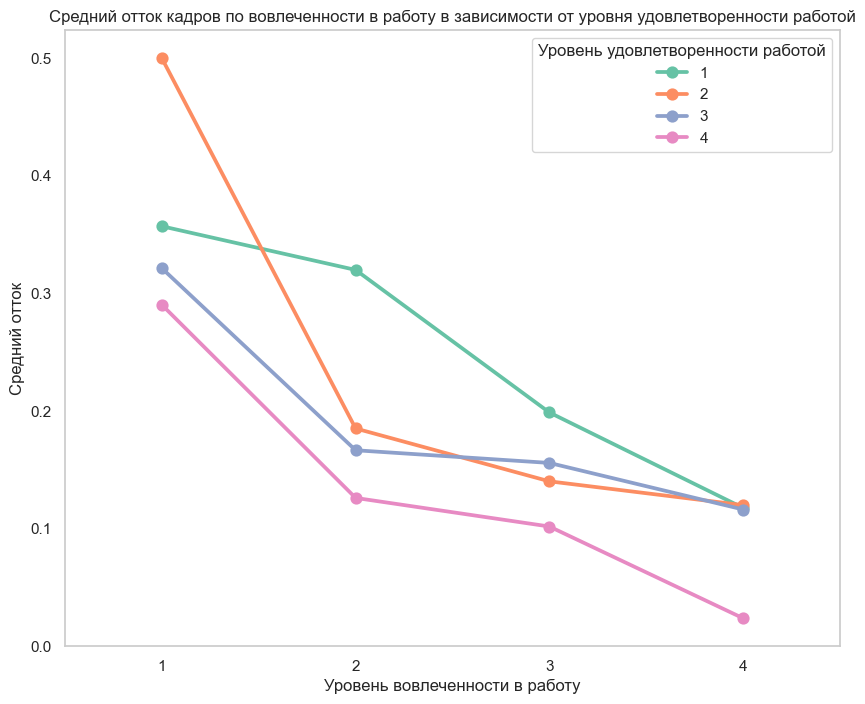

In [41]:
jobinv_jobsat = df.groupby(['JobInvolvement', 'JobSatisfaction'], as_index=False)['Attrition'].mean()

plt.figure(figsize=(10,8))
sns.pointplot(data=jobinv_jobsat, x='JobInvolvement', y='Attrition', hue = 'JobSatisfaction', palette='Set2')
plt.title('Средний отток кадров по вовлеченности в работу в зависимости от уровня удовлетворенности работой')
plt.xlabel('Уровень вовлеченности в работу')
plt.ylabel('Средний отток')
plt.grid(axis = 'y')
plt.legend(title = 'Уровень удовлетворенности работой')
plt.show()

Вывод: С увеличением вовлеченности в работу снижается средний уровень оттока для каждого уровня удовлетворенности работой. Наихудший показатель имеет группа с 2 уровнем удовлетворенности работой и 1 уровнем вовлеченности в работу.


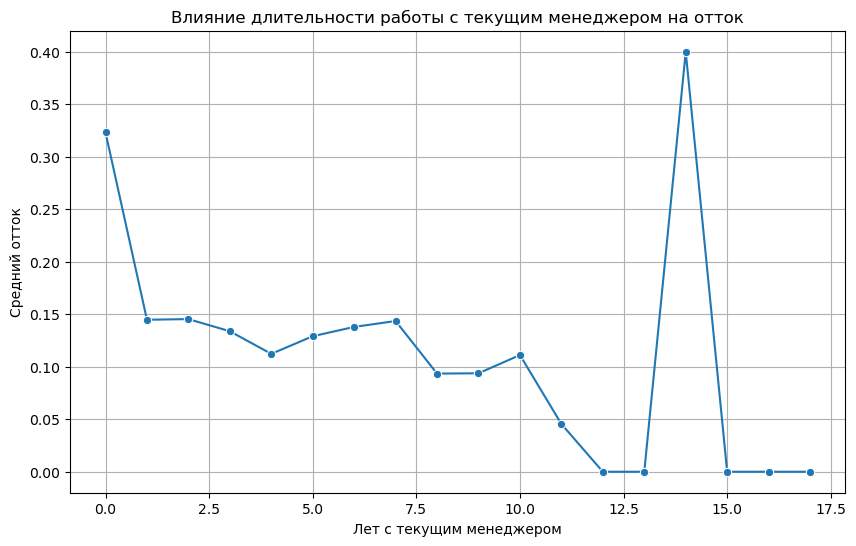

In [19]:
ywcm_attrition = df.groupby('YearsWithCurrManager', as_index=False)['Attrition'].mean()

plt.figure(figsize=(10,6))
sns.lineplot(data=ywcm_attrition, x='YearsWithCurrManager', y='Attrition', marker='o')
plt.title('Влияние длительности работы с одним менеджером на отток')
plt.xlabel('Лет с текущим менеджером')
plt.ylabel('Средний отток')
plt.grid()
plt.show()

Вывод: Работа с одним менеджером от 1 года до 7 лет не несет существенного снижения оттока кадров, однако после 7,5 лет наблюдается тенденция на снижения оттока, с выбросом на 14 годах и последующему абсолютному падению оттока к 15 годам.


# Анализ корреляций

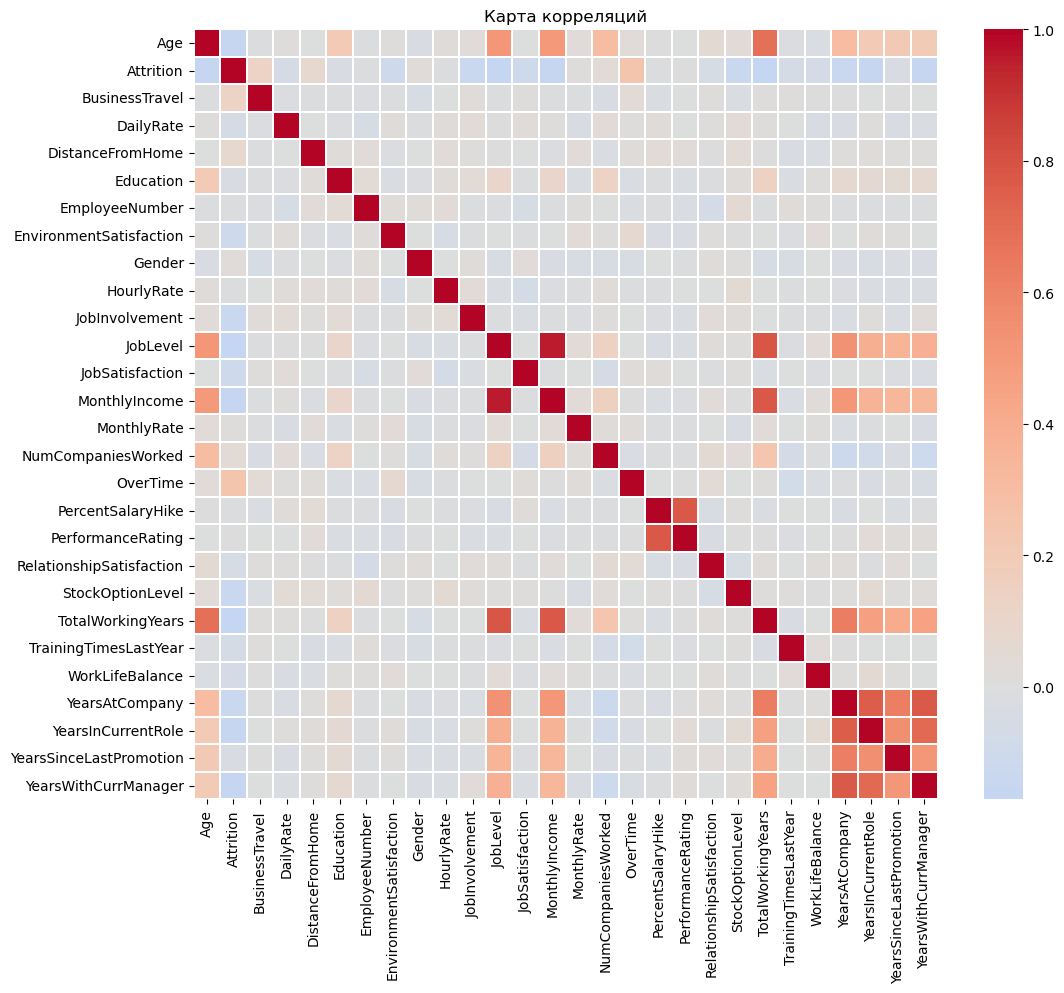

In [197]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

correl = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(data = correl, linewidths=0.3, linecolor='white', fmt='.2g', annot_kws={'size': 10, 'weight': 'bold'}, cmap="coolwarm", center=0,)
plt.title('Карта корреляций')
plt.show()

Вывод:

-	Большинство признаков имеют отрицательную корреляцию с оттоком.
-	Заметна отрицательная корреляция между временными факторами, такими как общим стажем работника и возрастом и оттоком кадров. То есть молодые сотрудники с невысоким общим стажем уходят чаще.
-	Присутствует слабая отрицательная корреляция для удовлетворенности средой в компании и вовлеченности в работу с оттоком. Таким образом, неудовлетворенные рабочей средой и мало вовлеченные сотрудники уходят из компании чаще.
-	Существует прямая корреляция между уровнем должности и месячной заработной платой, в свою очередь эти факторы снижают отток кадров.  Таким образом, чем выше должность и зарплата, тем ниже отток.
-	Прямо коррелируют временные показатели, такие как длительность работы сотрудника в компании, длительность пребывания на одной должности, время с последнего повышения и длительность пребывания с одним менеджером. Все параметры кроме времени с последнего повышения снижают отток кадров. 
-	Наибольший отток кадров связан с работой сверхурочно. Также, повышение количества командировок для сотрудника повышает вероятность увольнения, однако влияние слабее чем у переработок.
-	Также на карте заметна сильная положительная корреляция между оценкой производительности сотрудника и повышением его заработной платы, однако оба этих фактора слабо влияют на отток.



# Выводы и Рекомендации

Выводы:

-	Отток кадров носит структурный характер и наиболее выражен в определенных группах сотрудников. Наибольшему риску подвержены молодые одинокие специалисты с небольшим стажем работы, низкой зарплатой и низким уровнем должности. 
-	Значительное влияние на отток кадров оказывают организационные факторы. Переработки и командировки увеличивают вероятность увольнения, а высокая вовлеченность в работу и удовлетворенность рабочей средой эту вероятность снижают. Стоит отметить, что влияние каждого из факторов различается в зависимости от должности сотрудника. 
-	Среди отделов компании лидер по абсолютному оттоку – отдел научных исследований и развития, по относительному – отдел продаж.
-	Ключевыми факторами, снижающими отток, являются рост заработной платы, повышение уровня должности, увеличение общего стажа и возраста сотрудника, а также упомянутые вовлеченность в работу и удовлетворенность рабочей средой.

Рекомендации:

-	Обратить внимание и более глубоко исследовать происходяищее в отделе кадров и отделе продаж.
-	Усилить контроль переработок, и потенциально пересмотреть политику компании в отношении переработок.
-	Пересмотреть политику удержания сотрудников с малым стажем.
-	Необходимо учитывать интересы сотрудников, так как рост вовлеченности и удовлетворенности рабочей средой снижает вероятность ухода.

Заключение:

Проведенный анализ позволил выявить ключевые факторы, влияющие на отток сотрудников, и определить группы с повышенным риском увольнения. Установлено, что наибольшее влияние оказывают уровень оплаты труда, переработки, стаж работы, а также удовлетворенность и вовлеченность сотрудников. Основной отток сосредоточен среди одиноких молодых специалистов с невысоким доходом и небольшим стажем.

В результате исследования были предложены корректировка политики оплаты труда, контроль рабочей нагрузки, пересмотр системы адаптации сотрудников и изменение процессов управления на уровне подразделений. Полученные результаты могут быть использованы для будущего перехода на более гибкий подход к управлению. Реализация предложенных мер позволит снизить текучесть кадров, повысить стабильность и, соответственно, сократить затраты, связанные с подбором и обучением новых сотрудников.